In [1]:
import pandas as pd
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import scipy.signal as signal

In [2]:
def MakeFigure(ax, ax2, pilifer_signal, body_lateral, nectary_lateral):
    
    time = np.arange(len(pilifer_signal))*t
    
    ax.plot(time, body_lateral, label = 'body')
    ax.plot(time, nectary_lateral, 'k', label = 'nectary')
    ax.legend()
    ax.set_ylabel('position (in pixel)')
    ax.set_xlabel('Time (seconds)')
    
    
    ax2.plot(time, pilifer_signal, 'r', label = 'pilifer', alpha = 0.5)
    ax2.set_ylabel('Proboscis angle (in degree)')
    ax2.legend()

# Visualize the body, nectary and proboscis deflections at the base

In [2]:
filepath= './dataFolder/TrackingData_2022_11_10/thresholded_bodyparts/MV_fixed/'
trackPoints_files = glob.glob(filepath + '*bodyparts.csv')

filepath_another = './dataFolder/TrackingData_2022_11_10/ErrorAngle/MV_fixed/'
pilifer_signal_files = glob.glob(filepath_another + '*errorAngle.csv')

In [5]:
uber_data = []
for f in pilifer_signal_files:
    df = pd.DataFrame([])
    pilifer_signal = pd.read_csv(f, index_col=0)
    mothID = f.split('\\')[-1][:-15]
    
    trackPoints = pd.read_csv([file for file in trackPoints_files if mothID in file][0], index_col=0)
    
    pilifer_signal_smooth = signal.savgol_filter(pilifer_signal.values.flatten(), 5, 3)
    pilifer_signal_smooth_deg = pilifer_signal_smooth*(180/np.pi)
    
    body_lateral = trackPoints.loc[:,'body_x']
    nectary_lateral = trackPoints.loc[:,'nectary_x']
    
    df['nectary_lateral'] = nectary_lateral
    df['body_lateral'] = body_lateral
    df['pilifer_input'] = pilifer_signal_smooth_deg
    moth = [mothID] *len(df)
    df['mothID'] = moth
    uber_data.append(df)

uber_df = pd.concat(uber_data)

In [6]:
uber_df

,nectary_lateral,body_lateral,pilifer_input,mothID
0,351.150391,310.708984,-5.241272,MV_m11_130802
1,352.195312,311.617188,-3.519712,MV_m11_130802
2,352.873047,314.550781,-5.751968,MV_m11_130802
3,353.779297,314.920898,-5.714357,MV_m11_130802
4,353.757812,314.007812,-3.447474,MV_m11_130802
...,...,...,...,...
995,346.186523,330.408203,11.640980,MV_m9_130801
996,352.220703,336.902344,10.904920,MV_m9_130801
997,357.071289,339.431641,10.782730,MV_m9_130801
998,354.478516,339.273926,9.712485,MV_m9_130801


In [7]:
uber_df['_t'] = uber_df.groupby(uber_df['mothID']).cumcount()
stats = uber_df.groupby('_t')[uber_df.columns[:3]].agg(['mean', 'std'])

In [8]:
stats

nectary_lateral            body_lateral            pilifer_input          
               mean        std         mean        std          mean       std
_t                                                                            
0        365.671173  32.047910   368.908966  60.971966      0.917927  5.464653
1        366.669525  31.977258   367.972168  60.057478     -0.474104  5.488372
2        368.047607  31.949644   367.710754  59.328143     -1.040337  6.524064
3        368.629333  32.051317   368.763428  60.726734     -0.873838  7.156274
4        368.631287  32.073297   369.474770  59.675435     -1.386869  7.421299
..              ...        ...          ...        ...           ...       ...
995      351.140846  30.480933   351.514877  41.937268      1.778642  7.160723
996      355.615852  30.531562   353.895752  40.609932      0.413269  6.754605
997      361.279297  30.254228   357.299255  40.948418      0.063090  5.958608
998      359.604431  30.529301   359.066071  42.082779      0.368911  5.267966
999      358.551147  30.675323   360.928223  41.839399      2.055585  6.162334

[1000 rows x 6 columns]

C:\Users\tanvi.deora\AppData\Local\Temp\ipykernel_21388\1815824309.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


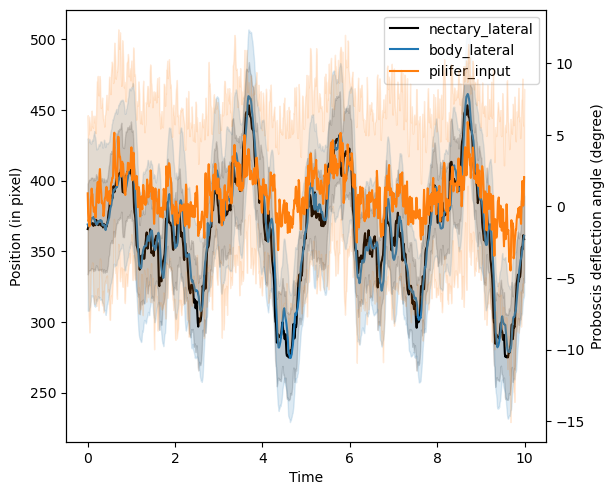

<Figure size 640x480 with 0 Axes>

In [30]:
fig_directory_name = './dataFolder/TrackingData_2022_11_10/ErrorAngle/Plots/'
freq = 100
dt = 1/freq

t = stats.index.values * dt  # time axis

fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.75,0.9])
ax2 = ax.twinx()

cols_left  = ['nectary_lateral', 'body_lateral']   # on primary axis
col_right  = 'pilifer_input'            # on twin axis

colors_left = ['black', 'tab:blue']
color_right = 'tab:orange'

# Right axis (third column)
m = stats[(col_right, 'mean')]
s = stats[(col_right, 'std')]
ax2.plot(t, m, color=color_right, label=col_right)
ax2.fill_between(t, m - s, m + s, color=color_right, alpha=0.15)

# Left axis (first two columns)
for c, col in zip(colors_left, cols_left):
    m = stats[(col, 'mean')].values
    s = stats[(col, 'std')].values
    ax.plot(t, m, color=c, label=col)
    ax.fill_between(t, m - s, m + s, color=c, alpha = 0.15)



ax.set_xlabel('Time')
ax.set_ylabel('Position (in pixel)')
ax2.set_ylabel('Proboscis deflection angle (degree)')

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

plt.savefig(fig_directory_name + 'MV_allMoth_tracks.png')

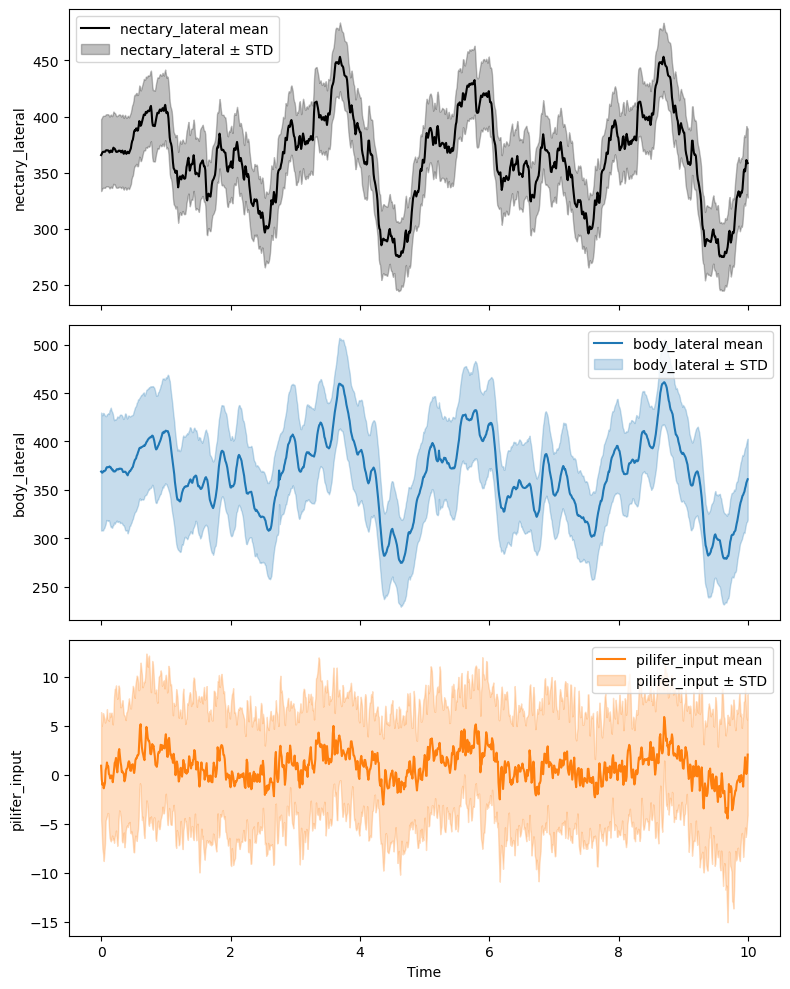

In [28]:
import matplotlib.pyplot as plt

cols  = ['nectary_lateral', 'body_lateral', 'pilifer_input']
colors = ['black', 'tab:blue', 'tab:orange']  # three distinct colors

freq = 100
dt = 1/freq
t = stats.index.values * dt  # time axis

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True)

for ax, col, color in zip(axes, cols, colors):
    m = stats[(col, 'mean')].values
    s = stats[(col, 'std')].values
    
    ax.plot(t, m, color=color, label=f'{col} mean')
    ax.fill_between(t, m - s, m + s, color=color, alpha=0.25, label=f'{col} ± STD')
    ax.set_ylabel(col)
    ax.legend(loc='best')

axes[-1].set_xlabel('Time')  # only label the x-axis on the bottom subplot

plt.tight_layout()
plt.show()